In [ ]:
%pip install -r requirements.txt

In [ ]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Подгрузим полезные функции
from utils import *



In [ ]:
# Подгрудаем датасет
heart_deaseases_dt = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
display(heart_deaseases_dt)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,0.0,1.0,1.0,1.0,18.0,0.0,0.0,2.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 ================================================== TRAIN RESULTS ================================================== 

ROC AUC score: 0.841

              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84    229787
         1.0       0.24      0.79      0.37     23893

    accuracy                           0.74    253680
   macro avg       0.61      0.77      0.60    253680
weighted avg       0.90      0.74      0.79    253680



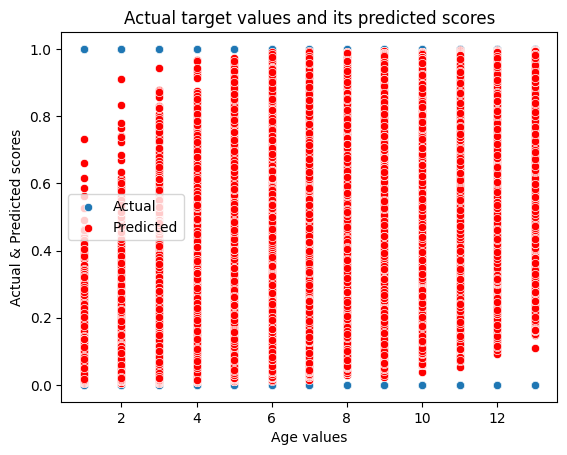

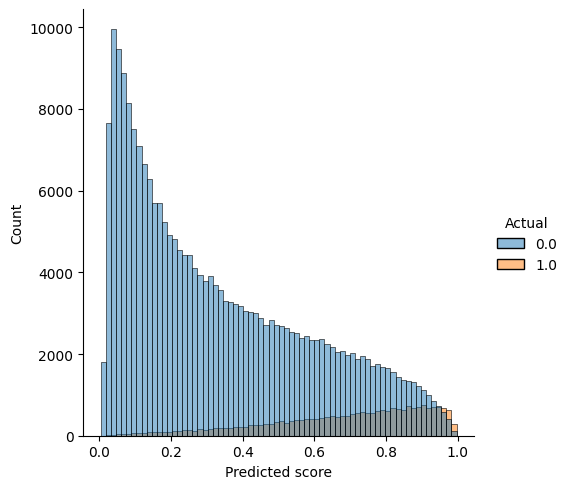

Predicted,0.000000,1.000000
Actual,,
0.000000,169295,60492
1.000000,4905,18988


In [ ]:
dt_logit, model_logit = train_binary(
    heart_deaseases_dt, target='HeartDiseaseorAttack',
    feature_names=['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'],
    plot_feature='Age',
    model_type='logit', pkg='sklearn', class_weight='balanced')

**Комментарии по полученным результатам:**


1.   Анализ метрик Precision и Recall
*   Precision для класса 1.0 (больные): 0.24
Это очень низкий показатель. Это означает, что модель дает огромное количество ложных тревог. Из всех предсказаний положительного класса большинство на самом деле являются здоровыми людьми.
*   Recall для класса 1.0 (больные): 0.79
Это довольно хороший показатель. Модель чувствительна к целевой группе и редко пропускает настоящих пациентов.
*   Precision для класса 0.0 (здоровые): 0.97
Отличный результат. Если модель сказала, что человек здоров, можно быть уверенным на 97%.
*   Recall для класса 0.0 (здоровые): 0.74
Модель пожертвовала точностью определения здоровых, чтобы поймать больше больных. 26% здоровых людей были ошибочно помечены как группа риска.


2.  Анализ метрик F1-macro и ROC-AUC


*   F1-macro: 0.60
Эта метрика подчеркивает дисбаланс в качестве работы модели. Из-за того, что по классу «больные» F1-мера очень низкая (0.37), общая макро-метрика получилась посредственной. Это говорит о том, что модель хорошо работает с доминирующим классом (здоровые), но плохо сбалансирована для решения главной задачи (поиск больных).
*   ROC-AUC: 0.841
Значение 0.84 — это очень хороший показатель. Он говорит о том, что модель в целом отлично разделяет два класса. Несмотря на низкий Precision, модель хорошо ранжирует пациентов: больные в среднем получают гораздо более высокие скоры, чем здоровые.





**Пример со 100 пациентами**
Чтобы ответить на этот вопрос, нужно пересчитать пропорции из большой выборки на маленькую (100 человек). Из условия задачи мы знаем распределение в популяции (из датасета): из 253 680 человек больных 23 893. Найдем вероятность встретить больного:

· Вероятность болезни ( prevalence): 23 893 / 253 680 ≈ 0.094 (9.4%)
· Вероятность здоровья: 1 - 0.094 = 0.906 (90.6%)

Если к нам пришло 100 человек, вероятностно среди них будет:

· 9.4 ≈ 9 больных
· 90.6 ≈ 91 здоровых

Теперь спроецируем работу модели на этих людей, используя Recall и Precision:

Шаг 1. Среди больных (9 человек):
Recall = 0.79. Значит, модель найдет: 9 * 0.79 = 7.11 (≈ 7 больных).
Пропустит (FN): 9 - 7 = 2 больных.

Шаг 2. Среди здоровых (91 человек):
Precision по больным у нас 0.24. Это значит, что из всех людей, кому модель поставит диагноз «болен» (назовем это число X), только 24% — это реально больные. Мы уже знаем, что реально больных среди предсказанных — 7 человек.
Формула Precision = TP / (TP + FP). Подставляем:
0.24 = 7 / (7 + FP)


Отсюда FP (ложные срабатывания) = 7 / 0.24 - 7 ≈ 29.16 - 7 = 22.16 (≈ 22 здоровых).

Итог по 100 пациентам:

· Корректно поставлено: Больным (7) + Здоровым (91 - 22 = 69) = 76 человек.
· Ошибочно поставлено (ложная тревога): 22 здоровых.
· Упущено больных: 2 человека.

**Вывод о применимости модели на практике**
Модель получилась средней или ограниченно пригодной. Ее нельзя использовать как автоматического диагноста, но можно использовать как фильтр.